# 02 — Feature Exploration

Once `src.features.build_features()` has materialised `data/processed/player_features.parquet`, this notebook explores what the table actually contains.

It does **not** rebuild the parquet — it loads the pre-computed file in a fraction of a second. The goal is to characterise the feature space before any modelling: which metrics are well populated, how they distribute, how strongly they correlate, and how their values differ across position groups. These observations motivate the choices made downstream in `03_clustering.ipynb` (which metrics to feed the PCA + KMeans pipeline) and in `04_demo.ipynb` (how to read role-match scores in context).

**Runtime:** loads the parquet (≈ 1 s) and runs vectorised pandas / matplotlib operations. Total under 30 seconds end to end.

## Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

FEATURES_PATH = PROJECT_ROOT / 'data' / 'processed' / 'player_features.parquet'
df = pd.read_parquet(FEATURES_PATH)

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
sns.set_style('whitegrid')

print(f'Loaded: {FEATURES_PATH.name}')
print(f'Shape : {df.shape[0]} players × {df.shape[1]} columns')

Loaded: player_features.parquet
Shape : 1836 players × 99 columns


## Population overview

The 450-minute season filter applied in `src.features.build_features` leaves only players with meaningful sample sizes. The position group is the most important categorical axis throughout the rest of the project: every normalisation and every role evaluation is intra-position.

In [2]:
summary = (df.groupby('position_group')
             .agg(n_players=('player_id', 'count'),
                  median_minutes=('minutes_total', 'median'),
                  total_minutes=('minutes_total', 'sum'))
             .sort_values('n_players', ascending=False))
summary

,n_players,median_minutes,total_minutes
position_group,,,
MF,539,1777.95,948582.35
FB,387,1639.85,667412.28
CB,355,1916.25,677073.98
AM,304,1561.81,497410.15
ST,251,1555.93,414233.20


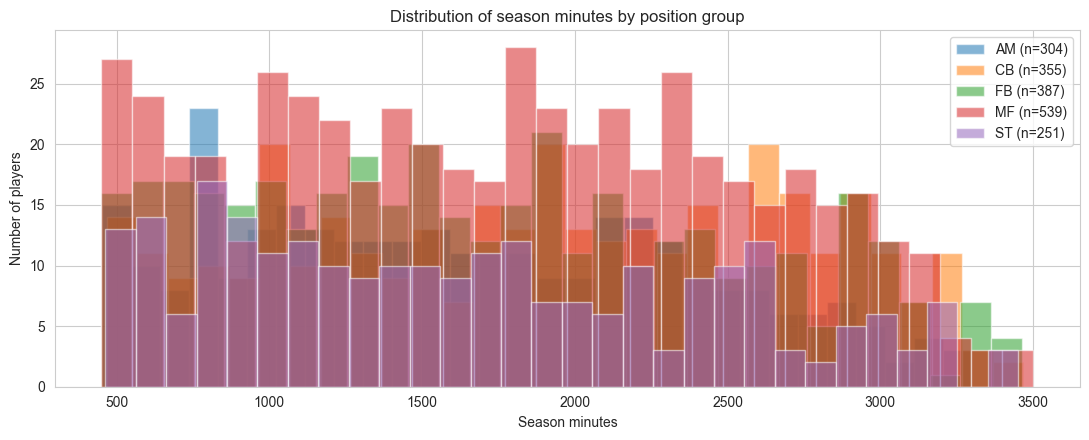

In [3]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for pos, sub in df.groupby('position_group'):
    ax.hist(sub['minutes_total'], bins=30, alpha=0.55, label=f'{pos} (n={len(sub)})')
ax.set_xlabel('Season minutes')
ax.set_ylabel('Number of players')
ax.set_title('Distribution of season minutes by position group')
ax.legend()
plt.tight_layout(); plt.show()

## Position-conditioned distributions

A handful of metrics tell most of the story when separated by position. The plots below contrast a passing metric, an attacking metric, a pressing metric, and a duel metric across the five groups. The vertical separation between the medians of each box is exactly the kind of structure the framework exploits — comparing a midfielder's `pressures_p90` to a striker's would be meaningless, but comparing a midfielder against other midfielders is informative.

C:\Users\andre\AppData\Local\Temp\ipykernel_61116\3982594008.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='position_group', y=metric, order=position_order,


C:\Users\andre\AppData\Local\Temp\ipykernel_61116\3982594008.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='position_group', y=metric, order=position_order,


C:\Users\andre\AppData\Local\Temp\ipykernel_61116\3982594008.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='position_group', y=metric, order=position_order,


C:\Users\andre\AppData\Local\Temp\ipykernel_61116\3982594008.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='position_group', y=metric, order=position_order,


C:\Users\andre\AppData\Local\Temp\ipykernel_61116\3982594008.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='position_group', y=metric, order=position_order,


C:\Users\andre\AppData\Local\Temp\ipykernel_61116\3982594008.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='position_group', y=metric, order=position_order,


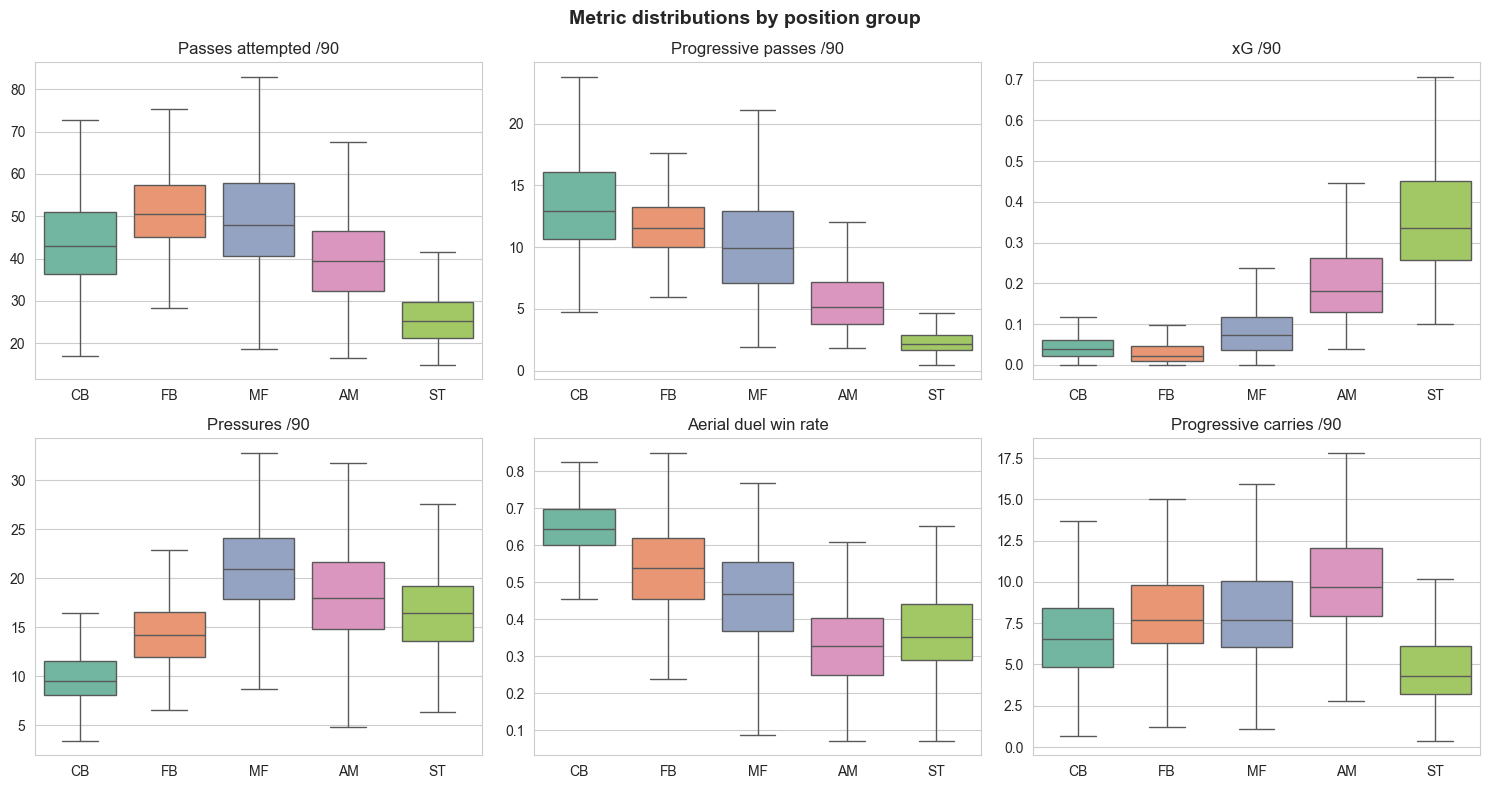

In [4]:
metrics_to_plot = [
    ('passes_attempted_p90',    'Passes attempted /90'),
    ('progressive_passes_p90',  'Progressive passes /90'),
    ('xG_p90',                  'xG /90'),
    ('pressures_p90',           'Pressures /90'),
    ('aerial_duel_win_rate',    'Aerial duel win rate'),
    ('progressive_carries_p90', 'Progressive carries /90'),
]

position_order = ['CB', 'FB', 'MF', 'AM', 'ST']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (metric, label) in zip(axes.flat, metrics_to_plot):
    sns.boxplot(data=df, x='position_group', y=metric, order=position_order,
                ax=ax, palette='Set2', showfliers=False)
    ax.set_title(label)
    ax.set_xlabel('')
    ax.set_ylabel('')
plt.suptitle('Metric distributions by position group', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Correlation structure within one position

Strongly correlated metrics carry redundant signal — they inflate the apparent dimensionality of the feature space without adding information, and they distort role-weight balances if both ends of a correlated pair are weighted independently in `role_profiles.yaml`. The heatmap below shows the correlation matrix of the per-90 columns within the centre-back population.

Expected patterns: passing volume metrics form one cluster (`passes_attempted`, `passes_completed`, `progressive_passes`); defensive volume metrics form another (`tackles`, `interceptions`, `clearances`); these two clusters anti-correlate moderately at CB (more clearances ↔ fewer passes, broadly the stylistic axis the YAML's BPD vs no-nonsense roles try to capture).

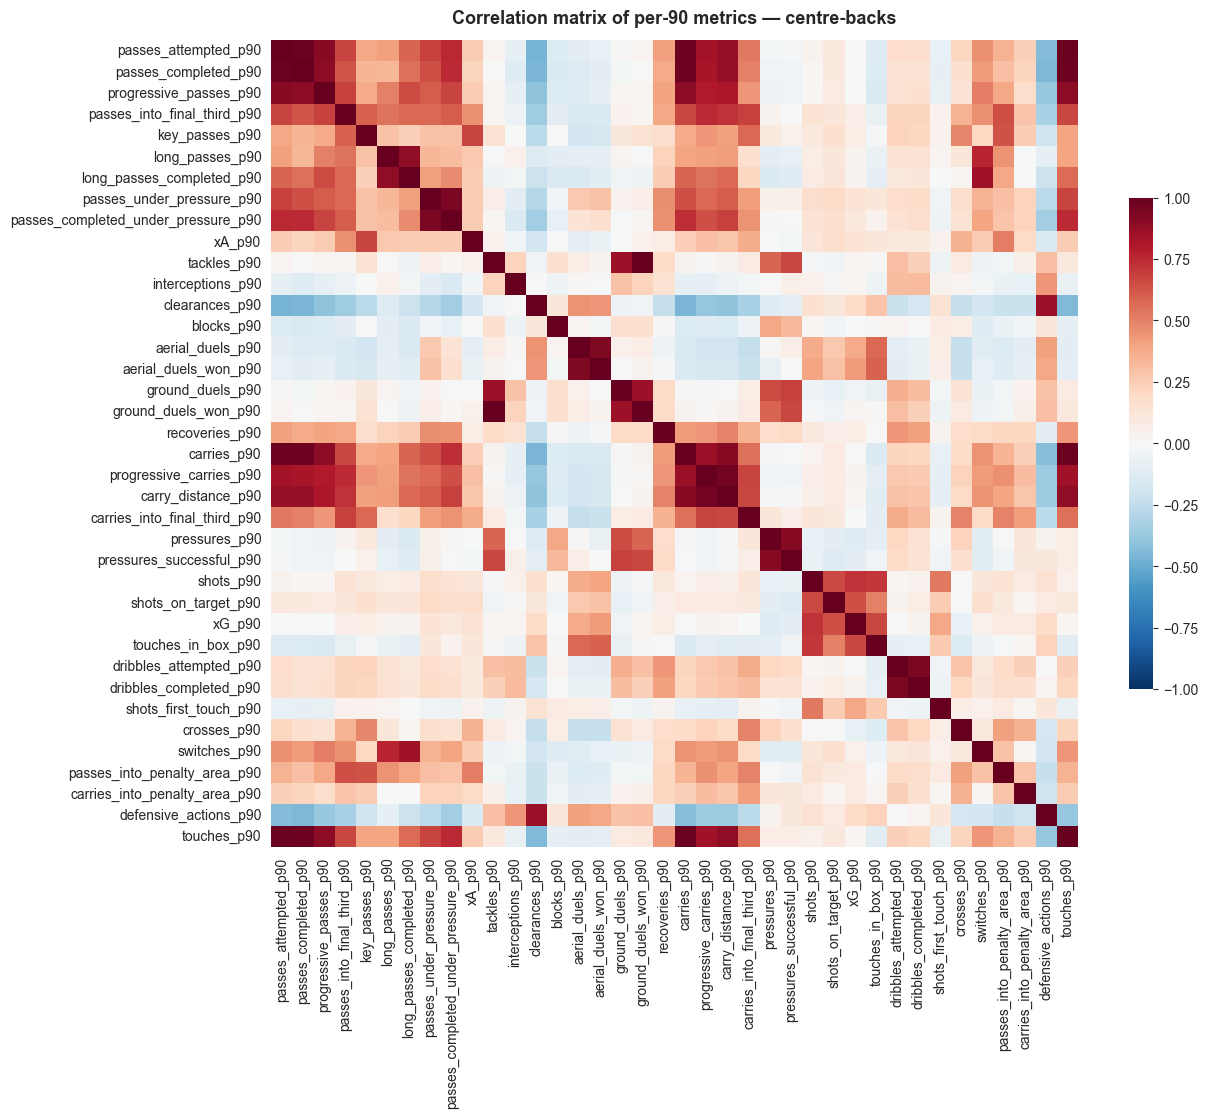

In [5]:
cb = df[df['position_group'] == 'CB']
p90_cols = [c for c in df.columns if c.endswith('_p90')]
# Drop low-signal metrics for readability
drop = {'fouls_committed_p90', 'fouls_won_p90', 'dispossessed_p90', 'miscontrols_p90'}
cols = [c for c in p90_cols if c not in drop]

corr = cb[cols].corr()
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, annot=False, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink': 0.6}, ax=ax)
ax.set_title('Correlation matrix of per-90 metrics — centre-backs',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout(); plt.show()

## Most discriminative metrics per position

Within a given position group, not every metric carries the same discriminative power. A metric on which every CB scores almost identically (low variance once MinMax-rescaled) cannot separate elite from average; a metric with large spread can. The table below reports, for each position, the ten metrics with the highest variance after intra-position MinMax normalisation — the *same* heuristic `matching.compare_players` uses to auto-select comparison axes.

In [6]:
from sklearn.preprocessing import MinMaxScaler

rate_like = ('pass_completion_rate', 'aerial_duel_win_rate', 'ground_duel_win_rate',
             'pressure_success_rate', 'shot_on_target_rate', 'xG_per_shot',
             'dribble_success_rate', 'pass_completion_under_pressure',
             'long_pass_completion_rate')
feature_cols = [c for c in df.columns if c.endswith('_p90')] + \
               [c for c in rate_like if c in df.columns]

discrim_rows = []
for pos in position_order:
    sub = df[df['position_group'] == pos][feature_cols].fillna(0.0)
    Xn = MinMaxScaler().fit_transform(sub)
    var = pd.Series(Xn.var(axis=0), index=feature_cols)
    discrim_rows.append({'position': pos,
                        'top_10_discriminative_metrics':
                            ', '.join(var.sort_values(ascending=False).head(10).index)})
discrim_df = pd.DataFrame(discrim_rows)

for _, row in discrim_df.iterrows():
    print(f"[{row['position']}] — most discriminative metrics:")
    for m in row['top_10_discriminative_metrics'].split(', '):
        print(f'   - {m}')
    print()

[CB] — most discriminative metrics:
   - dribble_success_rate
   - shot_on_target_rate
   - dribbles_completed_p90
   - dispossessed_p90
   - progressive_passes_p90
   - miscontrols_p90
   - long_pass_completion_rate
   - ground_duels_p90
   - interceptions_p90
   - dribbles_attempted_p90

[FB] — most discriminative metrics:
   - shot_on_target_rate
   - ground_duels_won_p90
   - tackles_p90
   - interceptions_p90
   - long_passes_p90
   - ground_duels_p90
   - passes_under_pressure_p90
   - carries_into_final_third_p90
   - carry_distance_p90
   - pressures_successful_p90

[MF] — most discriminative metrics:
   - shots_first_touch_p90
   - fouls_committed_p90
   - crosses_p90
   - pass_completion_rate
   - xG_per_shot
   - pass_completion_under_pressure
   - touches_in_box_p90
   - miscontrols_p90
   - key_passes_p90
   - dispossessed_p90

[AM] — most discriminative metrics:
   - carries_into_final_third_p90
   - pass_completion_under_pressure
   - recoveries_p90
   - fouls_committed_

## Takeaways

Three observations should be carried forward into the clustering and matching stages:

1. **Position-conditioned scoring is necessary, not optional.** The boxplots show that every meaningful metric has a strongly position-dependent distribution. Any global comparison would amount to penalising defenders for not shooting like strikers — a category error.

2. **The feature space is internally correlated.** The CB correlation heatmap reveals two distinct macro-clusters of metrics (passing-progression vs duels-clearances). PCA can compress this redundancy efficiently before clustering, which is the design choice made in `src.clustering.run_clustering`.

3. **The discriminative metrics vary by position.** What separates centre-backs (passing volume, duel win rates) is not what separates strikers (xG per shot, touches in box, dribble success). The clustering pipeline therefore fits an independent PCA + KMeans per position group, and the role taxonomy in `role_profiles.yaml` is also position-scoped.